--- Generating Chart: Observed vs Scenarios vs LSTM vs SARIMA (ANNUAL MEAN) ---
Success! Annual chart with LSTM and SARIMA saved at: ..\figuras\figure-hindcasting-validation-annual-with-sarima.pdf


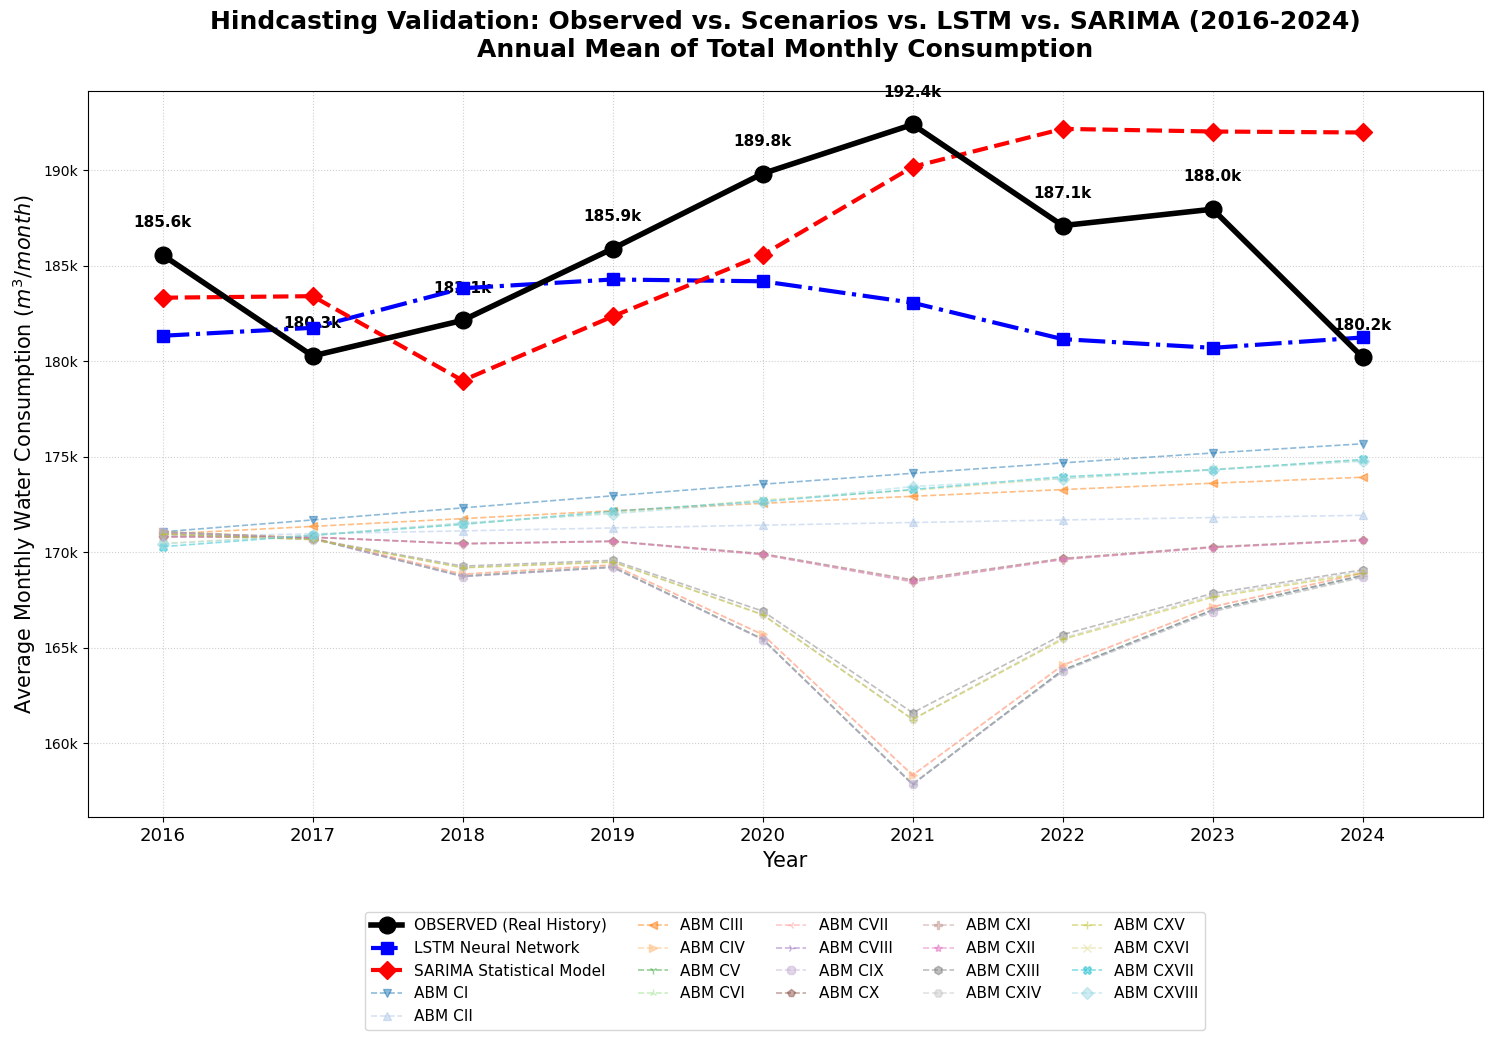

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
REAL_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'
LSTM_FILE = 'previsao_consumo_2016_2025.csv' 
SARIMA_FILE = 'previsao_consumo_sarima_2016_2025.csv' # Novo arquivo do SARIMA

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-hindcasting-validation-annual-with-sarima.pdf'

# Search Directories
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_IA = os.path.join(BASE_PATH, 'modelos IA')

def aggregate_annually_mean(df, date_col, value_cols):
    """ Aggregates monthly data points into annual means. """
    df_yearly = df.copy()
    df_yearly['Year'] = df_yearly[date_col].dt.year
    return df_yearly.groupby('Year')[value_cols].mean().reset_index()

def main():
    print("--- Generating Chart: Observed vs Scenarios vs LSTM vs SARIMA (ANNUAL MEAN) ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # A. Load Real Historical Data
    path_real = os.path.join(INPUT_DIR_INCLUDES, REAL_FILE)
    df_real = pd.read_csv(path_real, sep=';', decimal='.')
    df_real['Date'] = pd.to_datetime(df_real['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    df_real.rename(columns={'real_total_consumption': 'Real'}, inplace=True)

    # B. Load Simulation Results (ABM Scenarios)
    path_sim = os.path.join(INPUT_DIR_RESULTS, SIM_FILE)
    df_sim = pd.read_csv(path_sim, sep=';', decimal=',')
    if 'Ano' in df_sim.columns and 'Mes' in df_sim.columns:
        df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')
    
    scenario_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]

    # C. Load LSTM Prediction Results
    path_lstm = os.path.join(INPUT_DIR_IA, LSTM_FILE) 
    if os.path.exists(path_lstm):
        df_lstm = pd.read_csv(path_lstm, sep=';')
        df_lstm['Date'] = pd.to_datetime(df_lstm['Mes_Referencia'])
    else:
        print(f"Aviso: Arquivo {LSTM_FILE} não encontrado.")
        df_lstm = None

    # D. Load SARIMA Prediction Results (NOVO)
    path_sarima = os.path.join(INPUT_DIR_IA, SARIMA_FILE)
    if os.path.exists(path_sarima):
        df_sarima = pd.read_csv(path_sarima)
        df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
    else:
        print(f"Aviso: Arquivo {SARIMA_FILE} não encontrado.")
        df_sarima = None

    # Annual Aggregation
    df_real_mean = aggregate_annually_mean(df_real, 'Date', ['Real'])
    df_sim_mean = aggregate_annually_mean(df_sim, 'Date', scenario_cols)
    
    if df_lstm is not None:
        df_lstm_mean = aggregate_annually_mean(df_lstm, 'Date', ['Previsao_Consumo'])
        
    if df_sarima is not None:
        df_sarima_mean = aggregate_annually_mean(df_sarima, 'Date', ['Projected_Consumption'])

    # ==========================================
    # 3. Plotting
    # ==========================================
    fig, ax = plt.subplots(figsize=(18, 11))

    # --- A. Plotting 18 ABM Scenarios ---
    markers_list = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 'p', 'P', '*', 'h', 'H', '+', 'x', 'X', 'D']
    colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))
    
    for idx, col in enumerate(scenario_cols):
        scen_id = col.split('_')[0]
        ax.plot(df_sim_mean['Year'], df_sim_mean[col], color=colors[idx],
                linestyle='--', linewidth=1.2, alpha=0.5, 
                marker=markers_list[idx % len(markers_list)], markersize=6, label=f"ABM {scen_id}")

    # --- B. Plotting LSTM Prediction ---
    if df_lstm is not None:
        ax.plot(df_lstm_mean['Year'], df_lstm_mean['Previsao_Consumo'], label='LSTM Neural Network', 
                color='blue', linestyle='-.', linewidth=3, marker='s', markersize=9, zorder=25)

    # --- C. Plotting SARIMA Prediction (NOVO) ---
    if df_sarima is not None:
        ax.plot(df_sarima_mean['Year'], df_sarima_mean['Projected_Consumption'], label='SARIMA Statistical Model', 
                color='red', linestyle='--', linewidth=3, marker='D', markersize=9, zorder=26)

    # --- D. Plotting Historical Ground Truth (Highlighted) ---
    ax.plot(df_real_mean['Year'], df_real_mean['Real'], label='OBSERVED (Real History)', color='black',
            linestyle='-', linewidth=4, marker='o', markersize=12, zorder=30)

    # Annotations
    for x, y in zip(df_real_mean['Year'], df_real_mean['Real']):
        ax.annotate(f"{y/1000:.1f}k", (x, y), xytext=(0, 20), textcoords="offset points",
                    ha='center', fontsize=11, fontweight='bold', color='black')

    # ==========================================
    # 4. Final Formatting
    # ==========================================
    ax.set_ylabel('Average Monthly Water Consumption ($m^3/month$)', fontsize=15)
    ax.set_xlabel('Year', fontsize=15)
    
    years = df_real_mean['Year'].tolist()
    ax.set_xticks(years)
    ax.set_xticklabels(years, fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    ax.set_xlim(years[0]-0.5, years[-1]+0.8)
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.title('Hindcasting Validation: Observed vs. Scenarios vs. LSTM vs. SARIMA (2016-2025)\n'
              'Annual Mean of Total Monthly Consumption', 
              fontsize=18, fontweight='bold', pad=25)

    # Legend adjustment
    handles, labels = ax.get_legend_handles_labels()
    
    # Ordem de importância: Real -> LSTM -> SARIMA -> ABMs
    main_labels = ['OBSERVED (Real History)', 'LSTM Neural Network', 'SARIMA Statistical Model']
    order = []
    for m_l in main_labels:
        if m_l in labels: order.append(labels.index(m_l))
    
    for i, l in enumerate(labels):
        if 'ABM' in l: order.append(i)
    
    plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], 
               loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5, 
               fontsize=11, frameon=True)
    
    plt.subplots_adjust(bottom=0.22)

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Annual chart with LSTM and SARIMA saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()